
# Lab1_4: PDE_capacitor

In [1]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

### Potential and Electric field from a capacitor

#### Lab1_4_PDE_capacitor:

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

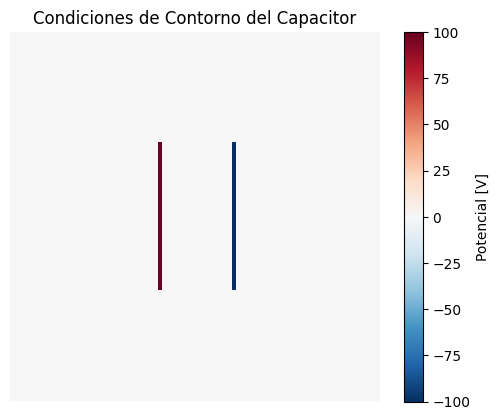

In [25]:
# Definamos las condiciones de contorno para el capacitor

N = 100                      # Tamaño de la grilla (NxN)
V = np.zeros((N, N))         # Matriz de potencial inicial

placa_largo = slice(30, 70)  # Extensión en y
pos_x1 = 40                  # Posición en x de placa 1
pos_x2 = 60                  # Posición en x de placa 2

V[placa_largo, pos_x1] = 100.0
V[placa_largo, pos_x2] = -100.0

plt.imshow(V, cmap="RdBu_r", origin="lower")
plt.colorbar(label='Potencial [V]')
plt.title('Condiciones de Contorno del Capacitor')
plt.axis('off')
plt.show()


In [34]:
# Solver LAPLACE Equation:
# Este es el método que construi para el lab1_3

def solve_laplace_tol_vec(u_0, x, y, tol=1e-6, max_iter=100_000):
    
    u = u_0.copy() 
    u_new = u.copy() 
  
    X, Y = np.meshgrid(x, y) 
    for k in range(max_iter): 
        u_new[1:-1, 1:-1] = 0.25 * ( u[2:, 1:-1] + # abajo 
                                    u[:-2, 1:-1] + # arriba 
                                    u[1:-1, 2: ] + # derecha 
                                    u[1:-1, :-2 ] # izquierda 
                                    ) 
        
        u_new[placa_largo, pos_x1] = 100.0
        u_new[placa_largo, pos_x2] = -100.0
        if np.linalg.norm(u_new - u, ord=np.inf) < tol: 
            print(f"Convergencia alcanzada en {k} iteraciones.") 
            return X, Y, u_new 
        u, u_new = u_new, u
         
    print("No se alcanzó la convergencia dentro del número máximo de iteraciones.") 
    return X, Y, u

Calculamos el potencial empleando la función de diferencias finitas programado para el lab1_3, agregandole una linea para mantener fijo el potencial en las placas.

Convergencia alcanzada en 8880 iteraciones.


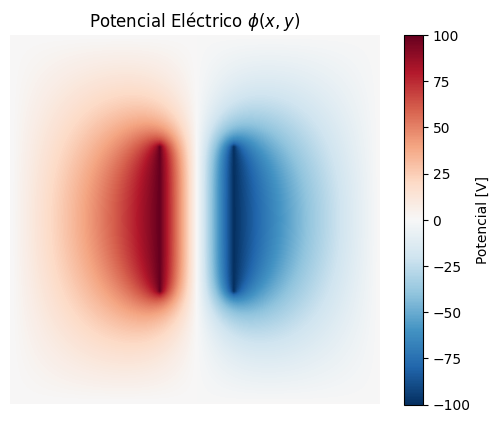

In [48]:
x = np.linspace(0, N-1, N)
y = np.linspace(0, N-1, N)

X, Y, V_sol = solve_laplace_tol_vec(V, x, y, tol=1e-6, max_iter=100_000)

plt.imshow(V_sol, cmap="RdBu_r", origin="lower", interpolation="bilinear")
plt.colorbar(label='Potencial [V]')

# plt.contour(V_sol, levels=15, colors='black', alpha=0.3)
plt.title('Potencial Eléctrico $\\phi(x,y)$')
plt.axis('off')
plt.show()


Ahora para encontrar el campo Electrico empleamos el gradiente

$$ -\vec{\nabla} \phi = \vec{E}$$

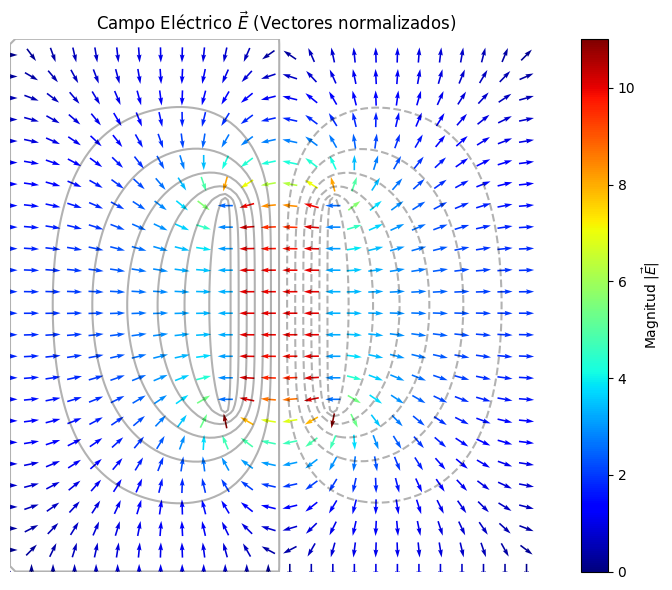

In [71]:
Ey, Ex = np.gradient(V_sol)
E_mag = np.sqrt(Ex**2 + Ey**2)

# E_mag_plot = np.clip(E_mag, 0, np.max(E_mag) * 0.3) 

# Normalización para visualización
Ex_norm = Ex / (E_mag + 1e-10)  # Evitar
Ey_norm = Ey / (E_mag + 1e-10)

# Submuestreo
step = 4
x_q = X[::step, ::step]
y_q = Y[::step, ::step]
ex_q = Ex_norm[::step, ::step]
ey_q = Ey_norm[::step, ::step]
emag_q = E_mag[::step, ::step]

# --- Gráfico de Flechas (Quiver) ---
fig, ax = plt.subplots(figsize=(8, 6))
quiver = ax.quiver(x_q, y_q, ex_q, ey_q, emag_q, 
                   cmap='jet',        
                   pivot='mid', 
                   scale=35,          # Escala constante para todas las flechas
                   width=0.003)       

ax.set_title('Campo Eléctrico $\\vec{E}$ (Vectores normalizados)')
ax.set_aspect('equal')
ax.set_axis_off()

ax.contour(V_sol, levels=15, colors='black', alpha=0.3)
# ax.imshow(V_sol, cmap="RdBu_r", origin="lower", interpolation="bilinear", alpha=0.8)

# Añadir la barra de color
fig.colorbar(quiver, ax=ax, label='Magnitud $|\\vec{E}|$')

plt.tight_layout()
plt.show()
